# Introduction

**MolCrysKit** is a Python library designed for the robust manipulation, repair, and standardization of molecular crystals. Unlike traditional tools that rely heavily on geometric heuristics, MolCrysKit adopts a **graph-theoretic approach** to handle complex crystallographic edge cases found in legacy data (e.g., CSD/CCDC).

This notebook demonstrates the core capabilities of the library, guiding you from raw, messy CIF files to "simulation-ready" structures.

Github: https://github.com/SchrodingersCattt/MolCrysKit


## Background & Motivation

Experimental crystallographic databases (e.g., CSD, ICSD) contain millions of structures, but a significant portion qualifies as **"Legacy Data"**—suffering from:
* **Missing Hydrogens:** Common in older X-ray diffraction data.
* **Structural Disorder:** Multiple occupancy sites and split positions.
* **Geometric Distortions:** Non-standard bond lengths or angles due to low resolution.
* **Complex Slabs:** Difficulties in cutting surface slabs for non-orthogonal (e.g., monoclinic) unit cells.

MolCrysKit aims to automate the **"Data Curation"** process, bridging the gap between experimental repositories and computational workflows (DFT/MD).

![alt](https://bohrium.oss-cn-zhangjiakou.aliyuncs.com/article/19853/00685c8b41844a37a73d0f3cf30236c9/cec338e2-9ee5-4032-8119-0130faa132ff.png)

## Key Functional Modules

This demo covers the following four pillars of structural manipulation:

### 1. Disorder Handling (Graph-based Resolution)
* **Problem:** Raw CIFs often contain "ghost" atoms (disordered sites) that physically overlap.
* **Solution:** The algorithm constructs a conflict graph, identifies **mutex groups** (mutually exclusive sets), and automatically resolves them to a single, physical configuration based on occupancy or user selection.

### 2. Robust Hydrogenation (Structure Repair)
* **Problem:** Legacy structures lack H atoms, or geometric addition fails for complex rings/chains.
* **Solution:** A topology-aware hydrogenation module that rebuilds missing protons based on local graph environments (hybridization detection) rather than simple distance checks. Ideal for repairing aromatic and hetero-cyclic systems.

### 3. Topological Slab Generation
* **Problem:** Cutting surfaces from non-orthogonal boxes (e.g., Monoclinic $\beta \neq 90^\circ$) often results in broken molecules or vacuum alignment issues.
* **Solution:** A specialized slab generator that strictly preserves molecular topology and handles arbitrary cell skewness using rigorous lattice vector transformations.

### 4. Defect Engineering
* **Problem:** Manually creating point defects (vacancies, substitutions) is tedious and error-prone.
* **Solution:** precise programmatic generation of point defects for high-throughput screening.

## Installation

In [11]:
# MolCrysKit is pre-installed in the Docker image.
# To install locally, run:
#   pip install git+https://github.com/SchrodingersCattt/MolCrysKit.git
# or, after cloning:
#   pip install .

# Optional visualisation extras (not required for core functionality):
! pip install nglview py3Dmol

Looking in indexes: https://mirrors.ivolces.com/pypi/simple/


# PART I. Tutorials



## 1. Generate Ordered Structures from Structures with Disordered Sites

In [12]:
from pathlib import Path
from ase.io import read
import nglview as nv

cif_path = Path("example/disordered_structures/DAP-4.cif")
if not cif_path.exists():
    raise FileNotFoundError(
        f"{cif_path} does not exist. Contact the author for help. "
        "E-mail: guomy26@mail2.sysu.edu.cn."
    )

print(f"Input CIF: {cif_path}")

ase_atoms_disordered = read(str(cif_path))

print(f"Number of atoms (disordered): {len(ase_atoms_disordered)}")
print(f"PBC: {ase_atoms_disordered.pbc}")

view_disordered = nv.show_ase(ase_atoms_disordered)
view_disordered.add_unitcell()
view_disordered


Input CIF: example/disordered_structures/DAP-4.cif


Number of atoms (disordered): 368
PBC: [ True  True  True]


/aisi-nas/guomingyu/SOFTWARE/ase/ase/io/cif.py:410: UserWarning: crystal system 'cubic' is not interpreted for space group Spacegroup(205, setting=1). This may result in wrong setting!
  warnings.warn(


NGLWidget()

In [13]:
import time
from molcrys_kit.analysis.disorder import (
    generate_ordered_replicas_from_disordered_sites,
)
from molcrys_kit.io import write_cif
import nglview as nv

start_time = time.time()
ordered_structures = generate_ordered_replicas_from_disordered_sites(
    str(cif_path),
    generate_count=4,
    method="random",
)
end_time = time.time()
print(f"Disorder resolution finished in {end_time - start_time:.2f} s")
print(f"Number of ordered replicas: {len(ordered_structures)}")

structure = ordered_structures[0]
ase_atoms_ordered = structure.to_ase()
print(f"Number of atoms (ordered): {len(ase_atoms_ordered)}")
print(f"PBC: {ase_atoms_ordered.pbc}")

output_cif = Path("DAP-4_resolved_random_0.cif")
write_cif(structure, str(output_cif))
print(f"Resolved structure written to: {output_cif}")

view_ordered = nv.show_ase(ase_atoms_ordered)
view_ordered.add_unitcell()
view_ordered


/aisi-nas/guomingyu/personal/MolCrysKit/molcrys_kit/analysis/disorder/process.py:43: UserWarning: The default value of primitive was changed from True to False in https://github.com/materialsproject/pymatgen/pull/3419. CifParser now returns the cell in the CIF file as is. If you want the primitive cell, please set primitive=True explicitly.
  structure = parser.parse_structures()[0]  # Get first structure


Disorder resolution finished in 2.40 s
Number of ordered replicas: 4
Number of atoms (ordered): 336
PBC: [ True  True  True]
Resolved structure written to: DAP-4_resolved_random_0.cif


NGLWidget()

## 2. Cut Topological Slab

In [14]:
from pathlib import Path
from molcrys_kit.io.cif import read_mol_crystal
from molcrys_kit.operations import generate_topological_slab

# 1. Loading ordered structure of DAP-4
cif_path = Path("DAP-4_resolved_random_0.cif")
if not cif_path.exists():
    raise FileNotFoundError(
        f"{cif_path} does not exist. Contact the author for help. "
        "E-mail: guomy26@mail2.sysu.edu.cn."
    )
print(f"Loading ordered crystal from {cif_path} ...")
crystal = read_mol_crystal(str(cif_path))
print("Ordered bulk crystal:")
print(f"  Number of molecules: {len(crystal.molecules)}")
print(f"  Total atoms: {sum(len(mol) for mol in crystal.molecules)}")
molecule_sizes = [len(mol) for mol in crystal.molecules]
print(f"  Unique molecule sizes: {sorted(set(molecule_sizes))}")


# Cut slab with molecular topology maintained
print("Generating topological slab.")
slab = generate_topological_slab(
    crystal=crystal,
    miller_indices=(1, 1, 1),
    layers=1,
    vacuum=5.0,
)

print("\nGenerated slab:")
print(f"  Number of molecules: {len(slab.molecules)}")
print(f"  Total atoms: {sum(len(mol) for mol in slab.molecules)}")

a, b, c, alpha, beta, gamma = slab.get_lattice_parameters()
print(
    f"  Lattice parameters:\n"
    f"    a = {a:.3f} Å, b = {b:.3f} Å, c = {c:.3f} Å\n"
    f"    α = {alpha:.2f}°, β = {beta:.2f}°, γ = {gamma:.2f}°"
)
write_cif(slab, "DAP-4_111_slab.cif")
ase_slab = slab.to_ase()
# ase_slab.wrap()
print(f"ASE slab atoms: {len(ase_slab)}")
print(f"PBC: {ase_slab.pbc}")
view_slab = nv.show_ase(ase_slab)
view_slab.add_unitcell()
view_slab.add_ball_and_stick()
view_slab

Loading ordered crystal from DAP-4_resolved_random_0.cif ...
Ordered bulk crystal:
  Number of molecules: 40
  Total atoms: 336
  Unique molecule sizes: [5, 22]
Generating topological slab.

Generated slab:
  Number of molecules: 40
  Total atoms: 336
  Lattice parameters:
    a = 20.402 Å, b = 20.402 Å, c = 13.329 Å
    α = 90.00°, β = 90.00°, γ = 60.00°
ASE slab atoms: 336
PBC: [ True  True False]


NGLWidget()

## 3. Defect

In [15]:
from pathlib import Path
import nglview as nv
from molcrys_kit.io.cif import read_mol_crystal
from molcrys_kit.analysis.stoichiometry import StoichiometryAnalyzer
from molcrys_kit.operations.defects import VacancyGenerator

cif_path = Path("DAP-4_111_slab.cif")
if not cif_path.exists():
    raise FileNotFoundError(
        f"{cif_path} does not exist. Contact the author for help. "
        "E-mail: guomy26@mail2.sysu.edu.cn."
    )

crystal = read_mol_crystal(str(cif_path))

analyzer = StoichiometryAnalyzer(crystal)
analyzer.print_species_summary()

generator = VacancyGenerator(crystal)

# Generate two different vacancy-defect crystals
defect_crystal_1 = generator.generate_vacancy(
    method='spatial_cluster',
    target_spec={"C6H14N2_1": 1, "H4N_1": 1, "ClO4_1": 3}
)
defect_crystal_2 = generator.generate_vacancy(
    method='spatial_cluster',
    target_spec={"H4N_1": 1, "ClO4_1": 1}
)

# Convert to ASE Atoms
ase_slab = crystal.to_ase()
ase_defect_1 = defect_crystal_1.to_ase()
ase_defect_2 = defect_crystal_2.to_ase()

print(f"Original slab atoms: {len(ase_slab)}")
print(f"Defect 1 atoms: {len(ase_defect_1)}")
print(f"Defect 2 atoms: {len(ase_defect_2)}")

# Visualize first defect structure
view_defect = nv.show_ase(ase_defect_1)
view_defect.add_unitcell()
view_defect.add_ball_and_stick(bondScale=1.2)
view_defect


Species Summary:
ID              Count    Formula         Reference Molecule Index  Notes               
-------------------------------------------------------------------------------------
C6H14N2_1       8        C6H14N2         0                                             
H4N_1           8        H4N             8                                             
ClO4_1          24       ClO4            16                                            
Original slab atoms: 336
Defect 1 atoms: 294
Defect 2 atoms: 326


NGLWidget()

## 4. Adding Hydrogen

In [16]:
cif_path = Path("example/H_lacking_structures/MAP.cif")
if not cif_path.exists():
    raise FileNotFoundError(
        f"{cif_path} does not exist. Contact the author for help. "
        "E-mail: guomy26@mail2.sysu.edu.cn."
    )

crystal = read_mol_crystal(str(cif_path))
ase_orig = crystal.to_ase()

view_orig = nv.show_ase(ase_orig)
view_orig.add_unitcell()
view_orig.add_ball_and_stick(bondScale=1.2)
view_orig

/root/miniconda3/lib/python3.12/site-packages/pymatgen/io/cif.py:1313: UserWarning: Missing elements H from PMG structure composition
  if struct := self._get_structure(data, primitive, symmetrized, check_occu=check_occu):


NGLWidget()

In [17]:
from molcrys_kit.operations import add_hydrogens

# Define hydrogenation rules for MAP
rules = [
    {"symbol": "N", "geometry": "tetrahedral", "target_coordination": 4},
    {"symbol": "O", "neighbor": ["Cl"], "geometry": "bend", "target_coordination": 1},
]

hydrogenated_crystal = add_hydrogens(crystal, rules=rules)

ase_hyd = hydrogenated_crystal.to_ase()
output_path = "MAP-H.cif"
write_cif(hydrogenated_crystal, output_path)
print(f"Hydrogenated structure saved to {output_path}")

view_hyd = nv.show_ase(ase_hyd)
view_hyd.add_unitcell()
view_hyd.add_ball_and_stick(bondScale=1.2)
view_hyd



--- Checking Carbon 0 ---
Position: [1.05460539 5.426525   5.46244955]
Coordination Number: 1
Neighbor Distances: [1.5369000264666888]
Angle Sum: 0.00
Prediction: Unsure state (Coord=1)

--- Checking Carbon 0 ---
Position: [ 4.13538177  1.591525   -0.07676278]
Coordination Number: 1
Neighbor Distances: [1.5369000264666892]
Angle Sum: 0.00
Prediction: Unsure state (Coord=1)

--- Checking Carbon 0 ---
Position: [9.32536893 2.243475   5.30892398]
Coordination Number: 1
Neighbor Distances: [1.53690002646669]
Angle Sum: 0.00
Prediction: Unsure state (Coord=1)

--- Checking Carbon 1 ---
Position: [ 6.24459255  6.078475   10.84813632]
Coordination Number: 1
Neighbor Distances: [1.5369000264666905]
Angle Sum: 0.00
Prediction: Unsure state (Coord=1)

--- Checking Carbon 0 ---
Position: [8.03825212 2.720549   0.64766567]
Coordination Number: 1
Neighbor Distances: [1.5074555029984769]
Angle Sum: 0.00
Prediction: Unsure state (Coord=1)

--- Checking Carbon 1 ---
Position: [7.53170937 6.555549   2

NGLWidget()

# PART II. Benchmarks

## 1. Slab Generation

ASE time consume:  0.0017533302307128906
336
PMG time consume:  37.56564402580261
Molcrys-kit time consume:  0.10870099067687988


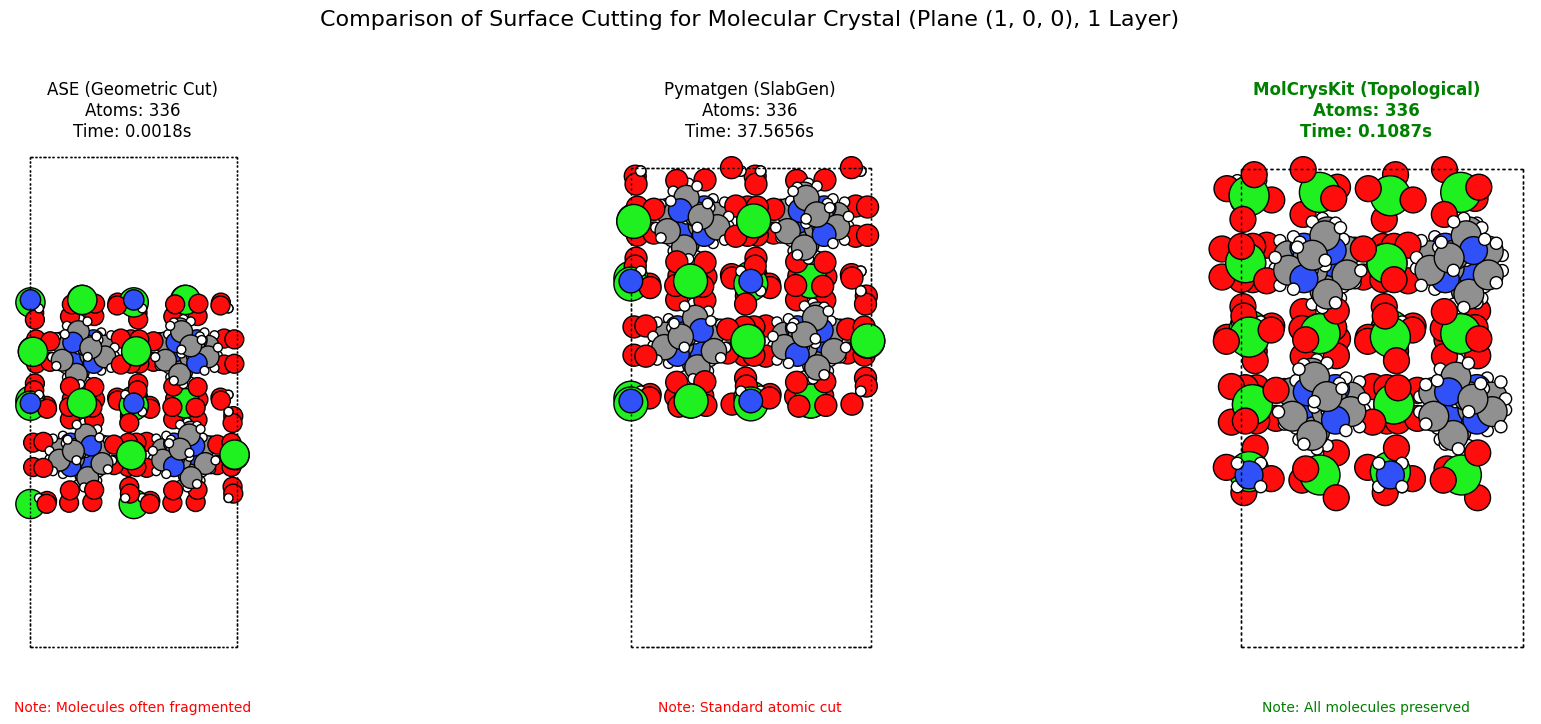

In [18]:
import time
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from ase.visualize.plot import plot_atoms
from ase.build import surface as ase_surface

# MolCrysKit imports
from molcrys_kit.io.cif import read_mol_crystal
from molcrys_kit.operations import generate_topological_slab

# Pymatgen imports
from pymatgen.core.structure import Structure
from pymatgen.core.surface import SlabGenerator
from pymatgen.io.ase import AseAtomsAdaptor

cif_path = Path("DAP-4_resolved_random_0.cif")

MILLER = (1, 0, 0)
LAYERS = 1
VACUUM = 10.0

crystal = read_mol_crystal(str(cif_path))
original_ase = crystal.to_ase()
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# ---------------- 1. ASE Direct Cut ----------------
start = time.time()
try:
    ase_slab = ase_surface(original_ase, MILLER, layers=LAYERS, vacuum=VACUUM)
    time_ase = time.time() - start
    plot_atoms(ase_slab, axes[0], rotation="90x,90y,0z")
    axes[0].set_title(f"ASE (Geometric Cut)\nAtoms: {len(ase_slab)}\nTime: {time_ase:.4f}s", fontsize=12)
except Exception as e:
    axes[0].set_text(0.5, 0.5, f"ASE Error: {e}")
axes[0].set_axis_off()
print("ASE time consume: ", time_ase)

# ---------------- 2. Pymatgen Slab (Standard) ----------------
start = time.time()
pmg_struct = AseAtomsAdaptor.get_structure(original_ase)
print(len(pmg_struct))
slabgen = SlabGenerator(
    pmg_struct, 
    miller_index=MILLER, 
    min_slab_size=1.0, 
    min_vacuum_size=1, 
    in_unit_planes=True,
    center_slab=False,
    primitive=False
)
slabs = slabgen.get_slabs(
    repair=True,
    ftol=0.2,      # default 0.1
    ztol=0.2,      # default 0.1
    tol=0.1        # default 0.0
)
pmg_slab = AseAtomsAdaptor.get_atoms(slabs[0]) if slabs else original_ase
time_pmg = time.time() - start

plot_atoms(pmg_slab, axes[1], rotation="90x,90y,0z")
axes[1].set_title(f"Pymatgen (SlabGen)\nAtoms: {len(pmg_slab)}\nTime: {time_pmg:.4f}s", fontsize=12)
axes[1].set_axis_off()
print("PMG time consume: ", time_pmg)

# ---------------- 3. MolCrysKit (Topological) ----------------
start = time.time()
molck_slab_obj = generate_topological_slab(
    crystal, 
    miller_indices=MILLER, 
    layers=LAYERS, 
    vacuum=VACUUM
)
molck_slab = molck_slab_obj.to_ase()
# molck_slab.wrap()
time_molck = time.time() - start
print("Molcrys-kit time consume: ", time_molck)

plot_atoms(molck_slab, axes[2], rotation="90x,90y,0z")
axes[2].set_title(f"MolCrysKit (Topological)\nAtoms: {len(molck_slab)}\nTime: {time_molck:.4f}s", fontsize=12, fontweight='bold', color='green')
axes[2].set_axis_off()

plt.suptitle(f"Comparison of Surface Cutting for Molecular Crystal (Plane {MILLER}, {LAYERS} Layer)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

axes[0].text(0.5, -0.1, "Note: Molecules often fragmented", transform=axes[0].transAxes, ha='center', color='red')
axes[1].text(0.5, -0.1, "Note: Standard atomic cut", transform=axes[1].transAxes, ha='center', color='red')
axes[2].text(0.5, -0.1, "Note: All molecules preserved", transform=axes[2].transAxes, ha='center', color='green')

plt.show()

In [19]:
import time
import numpy as np
import matplotlib.pyplot as plt

from ase.build import bulk, surface
from ase.io import write
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.core.surface import SlabGenerator

from molcrys_kit.structures import MolecularCrystal
from molcrys_kit.operations import generate_topological_slab

# ---------------- Parameters ----------------
sizes_ase_molck = list(range(1, 9))   # ASE / MolCrysKit: 1–8
sizes_pmg = list(range(1, 5))         # pymatgen: 1–4

MILLER = (1, 0, 0)
LAYERS = 1
VACUUM = 10.0
A_CU = 3.615

atoms_counts = []
time_ase = []
time_pmg = []
time_molck = []

# ---------------- Loop ----------------
for n in sizes_ase_molck:
    # Build fcc Cu bulk
    cu_bulk = bulk("Cu", "fcc", a=A_CU, cubic=True) * (n, n, n)
    natoms = len(cu_bulk)
    atoms_counts.append(natoms)


    # ---------- ASE ----------
    t0 = time.time()
    ase_slab = surface(
        cu_bulk,
        MILLER,
        layers=LAYERS,
        vacuum=VACUUM,
        periodic=True,
    )
    time_ase.append(time.time() - t0)

    # ---------- pymatgen (n <= 4) ----------
    if n in sizes_pmg:
        t0 = time.time()
        pmg_bulk = AseAtomsAdaptor.get_structure(cu_bulk)
        slabgen = SlabGenerator(
            pmg_bulk,
            miller_index=MILLER,
            min_slab_size=1.0,
            min_vacuum_size=VACUUM,
            center_slab=True,
            in_unit_planes=True,
            primitive=False,
        )
        slabs = slabgen.get_slabs(symmetrize=False)
        pmg_slab = slabs[0]
        _ = AseAtomsAdaptor.get_atoms(pmg_slab)
        time_pmg.append(time.time() - t0)
    else:
        time_pmg.append(np.nan)

    # ---------- MolCrysKit ----------
    t0 = time.time()
    crystal = MolecularCrystal.from_ase(cu_bulk)
    molck_slab = generate_topological_slab(
        crystal,
        miller_indices=MILLER,
        layers=LAYERS,
        vacuum=VACUUM,
    )
    _ = molck_slab.to_ase()
    time_molck.append(time.time() - t0)

    print(
        f"n={n:2d} | atoms={natoms:5d} | "
        f"ASE={time_ase[-1]:.3e}s | "
        f"PMG={time_pmg[-1]:.3e}s | "
        f"MolCrysKit={time_molck[-1]:.3e}s"
    )


n= 1 | atoms=    4 | ASE=1.331e-03s | PMG=1.852e-02s | MolCrysKit=1.317e-02s


n= 2 | atoms=   32 | ASE=9.043e-04s | PMG=3.594e-01s | MolCrysKit=1.065e-01s
n= 3 | atoms=  108 | ASE=9.985e-04s | PMG=4.690e+00s | MolCrysKit=3.703e-01s
n= 4 | atoms=  256 | ASE=1.285e-03s | PMG=3.721e+01s | MolCrysKit=7.052e-01s
n= 5 | atoms=  500 | ASE=1.407e-03s | PMG=nans | MolCrysKit=1.331e+00s
n= 6 | atoms=  864 | ASE=1.628e-03s | PMG=nans | MolCrysKit=2.411e+00s
n= 7 | atoms= 1372 | ASE=1.860e-03s | PMG=nans | MolCrysKit=3.664e+00s
n= 8 | atoms= 2048 | ASE=2.091e-03s | PMG=nans | MolCrysKit=5.804e+00s


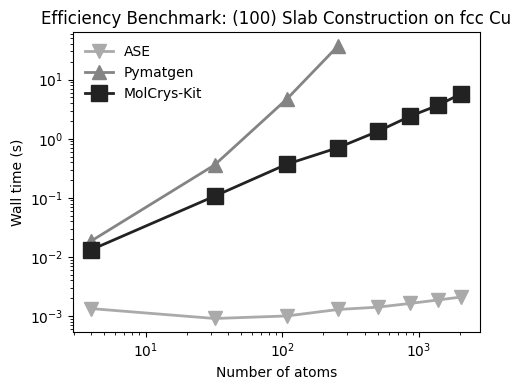

In [20]:

# ---------------- Plot ----------------
plt.figure(figsize=(5, 4))
plt.plot(atoms_counts, time_ase, marker="v", markersize=10, c="#aaaaaa", label="ASE", linewidth=2)
plt.plot(atoms_counts, time_pmg, marker="^", markersize=10, c="#848484", label="Pymatgen", linewidth=2)
plt.plot(atoms_counts, time_molck, marker="s", markersize=12, c="#222222", label="MolCrys-Kit", linewidth=2)

plt.xlabel("Number of atoms")
plt.ylabel("Wall time (s)")
plt.yscale('log')
plt.xscale('log')
plt.title("Efficiency Benchmark: (100) Slab Construction on fcc Cu")
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()
